# Bangalore PG Accommodation Analytics (2025–2027)

## Introduction
This project analyzes PG accommodation data in Bangalore city.
The dataset contains 1080 rows and 14 columns covering various
PG listings across locations like HSR Layout, Koramangala, BTM Layout etc.

## Objective
- To clean and analyze real-world messy PG data
- To find insights about rent, location, amenities
- To visualize trends using Matplotlib and Seaborn

## 1) Importing the libraries for working in dataset

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2) Loading the Dataset

In [2]:
data = pd.read_csv(r"C:\Users\ELCOT\Downloads\bangalore_pg_messy.csv")
data.head()

,PG_ID,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,1,Urban Nest 48,hsr layout,2 Sharing,6678.74,Available,Male,NO,yes,5.98,1.9,2027-06-10,Professional,3.2
1,2,Metro PG 7,btm layout,3 Sharing,5294.73,Available,FEMALE,yes,yes,0.95,1.8,02/06/2027,Professional,4.4
2,3,Comfort Stay 15,Hebbal,4 Sharing,4950.66,Full,Female,Yes,NO,3.16,8.8,04-Oct-2025,Professional,2.8
3,4,Green Valley PG 5,JP Nagar,single,8228.16,Full,Male,No,Yes,7.55,2.9,2026/08/22,Both,4.5
4,5,Budget Stay 6,jayanagar,4 sharing,5714.34,Partially Full,FEMALE,yes,No,6.92,7.8,26-Jun-2027,Professional,1.6


## 3) Data Cleaning

The dataset has missing values, duplicates, inconsistent values and mixed date formats. We will fix all these issues below.

In [3]:
data.duplicated().sum()

np.int64(0)

In [4]:
data.drop_duplicates()

,PG_ID,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,1,Urban Nest 48,hsr layout,2 Sharing,6678.74,Available,Male,NO,yes,5.98,1.9,2027-06-10,Professional,3.2
1,2,Metro PG 7,btm layout,3 Sharing,5294.73,Available,FEMALE,yes,yes,0.95,1.8,02/06/2027,Professional,4.4
2,3,Comfort Stay 15,Hebbal,4 Sharing,4950.66,Full,Female,Yes,NO,3.16,8.8,04-Oct-2025,Professional,2.8
3,4,Green Valley PG 5,JP Nagar,single,8228.16,Full,Male,No,Yes,7.55,2.9,2026/08/22,Both,4.5
4,5,Budget Stay 6,jayanagar,4 sharing,5714.34,Partially Full,FEMALE,yes,No,6.92,7.8,26-Jun-2027,Professional,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,1076,Sunshine PG 49,Whitefield,2 sharing,10208.48,Available,unisex,no,Yes,3.09,6.7,17-Apr-2026,both,3.3
1076,1077,Sunshine PG 34,BTM Layout,4 sharing,5808.86,Partially Full,unisex,NaN,NO,4.36,6.8,20/05/2025,both,4.6
1077,1078,Sri Sai PG 29,JP NAGAR,single,NaN,Partially Full,Female,NO,no,6.89,9.5,03-08-2025,Both,3.5
1078,1079,Sunshine PG 15,Indiranagar,2 sharing,3851.62,Full,MALE,no,No,1.20,7.8,22-11-2026,PROFESSIONAL,3.1


In [5]:
data.isna().sum()

PG_ID                    0
PG_Name                  0
Location                 0
Room_Type                0
Monthly_Rent            44
Occupancy_Status         0
Gender                   0
Food_Included           37
WiFi_Available          19
Distance_to_Metro_km    18
Amenities_Score         39
Listed_Date              0
Target_Tenant            0
Rating                  31
dtype: int64

In [6]:
data.drop(columns="PG_ID", inplace=True)

In [7]:
data.columns

Index(['PG_Name', 'Location', 'Room_Type', 'Monthly_Rent', 'Occupancy_Status',
       'Gender', 'Food_Included', 'WiFi_Available', 'Distance_to_Metro_km',
       'Amenities_Score', 'Listed_Date', 'Target_Tenant', 'Rating'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PG_Name               1080 non-null   object 
 1   Location              1080 non-null   object 
 2   Room_Type             1080 non-null   object 
 3   Monthly_Rent          1036 non-null   float64
 4   Occupancy_Status      1080 non-null   object 
 5   Gender                1080 non-null   object 
 6   Food_Included         1043 non-null   object 
 7   WiFi_Available        1061 non-null   object 
 8   Distance_to_Metro_km  1062 non-null   float64
 9   Amenities_Score       1041 non-null   float64
 10  Listed_Date           1080 non-null   object 
 11  Target_Tenant         1080 non-null   object 
 12  Rating                1049 non-null   float64
dtypes: float64(4), object(9)
memory usage: 109.8+ KB


In [9]:
data["Monthly_Rent"].isna().sum()

np.int64(44)

In [10]:
data["Monthly_Rent"] = data["Monthly_Rent"].fillna(data["Monthly_Rent"].mean())

In [11]:
data["Monthly_Rent"].isna().sum()

np.int64(0)

In [12]:
data["Location"].head()

0    hsr layout
1    btm layout
2        Hebbal
3      JP Nagar
4     jayanagar
Name: Location, dtype: object

In [13]:
data["Location"] = data["Location"].str.capitalize()
data["Location"].head()

0    Hsr layout
1    Btm layout
2        Hebbal
3      Jp nagar
4     Jayanagar
Name: Location, dtype: object

In [14]:
data["Gender"] = data["Gender"].str.capitalize()
data["Gender"]

0         Male
1       Female
2       Female
3         Male
4       Female
         ...  
1075    Unisex
1076    Unisex
1077    Female
1078      Male
1079      Male
Name: Gender, Length: 1080, dtype: object

In [15]:
data["Room_Type"] = data["Room_Type"].str.title()
data["Room_Type"]

0       2 Sharing
1       3 Sharing
2       4 Sharing
3          Single
4       4 Sharing
          ...    
1075    2 Sharing
1076    4 Sharing
1077       Single
1078    2 Sharing
1079    3 Sharing
Name: Room_Type, Length: 1080, dtype: object

In [16]:
data.head()

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,Urban Nest 48,Hsr layout,2 Sharing,6678.74,Available,Male,NO,yes,5.98,1.9,2027-06-10,Professional,3.2
1,Metro PG 7,Btm layout,3 Sharing,5294.73,Available,Female,yes,yes,0.95,1.8,02/06/2027,Professional,4.4
2,Comfort Stay 15,Hebbal,4 Sharing,4950.66,Full,Female,Yes,NO,3.16,8.8,04-Oct-2025,Professional,2.8
3,Green Valley PG 5,Jp nagar,Single,8228.16,Full,Male,No,Yes,7.55,2.9,2026/08/22,Both,4.5
4,Budget Stay 6,Jayanagar,4 Sharing,5714.34,Partially Full,Female,yes,No,6.92,7.8,26-Jun-2027,Professional,1.6


In [17]:
data["Occupancy_Status"] = data["Occupancy_Status"].str.title()
data["Occupancy_Status"]

0            Available
1            Available
2                 Full
3                 Full
4       Partially Full
             ...      
1075         Available
1076    Partially Full
1077    Partially Full
1078              Full
1079    Partially Full
Name: Occupancy_Status, Length: 1080, dtype: object

In [18]:
data["Food_Included"] = data["Food_Included"].str.capitalize()
data["Food_Included"]

0        No
1       Yes
2       Yes
3        No
4       Yes
       ... 
1075     No
1076    NaN
1077     No
1078     No
1079     No
Name: Food_Included, Length: 1080, dtype: object

In [19]:
data["WiFi_Available"] = data["WiFi_Available"].str.capitalize()
data["WiFi_Available"]

0       Yes
1       Yes
2        No
3       Yes
4        No
       ... 
1075    Yes
1076     No
1077     No
1078     No
1079     No
Name: WiFi_Available, Length: 1080, dtype: object

In [20]:
data.isna().sum()

PG_Name                  0
Location                 0
Room_Type                0
Monthly_Rent             0
Occupancy_Status         0
Gender                   0
Food_Included           37
WiFi_Available          19
Distance_to_Metro_km    18
Amenities_Score         39
Listed_Date              0
Target_Tenant            0
Rating                  31
dtype: int64

In [21]:
data["Location"] = data["Location"].str.title()

In [22]:
data["Target_Tenant"] = data["Target_Tenant"].str.capitalize()

In [23]:
data.head()

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,Urban Nest 48,Hsr Layout,2 Sharing,6678.74,Available,Male,No,Yes,5.98,1.9,2027-06-10,Professional,3.2
1,Metro PG 7,Btm Layout,3 Sharing,5294.73,Available,Female,Yes,Yes,0.95,1.8,02/06/2027,Professional,4.4
2,Comfort Stay 15,Hebbal,4 Sharing,4950.66,Full,Female,Yes,No,3.16,8.8,04-Oct-2025,Professional,2.8
3,Green Valley PG 5,Jp Nagar,Single,8228.16,Full,Male,No,Yes,7.55,2.9,2026/08/22,Both,4.5
4,Budget Stay 6,Jayanagar,4 Sharing,5714.34,Partially Full,Female,Yes,No,6.92,7.8,26-Jun-2027,Professional,1.6


In [24]:
data["Listed_Date"].dtypes

dtype('O')

In [25]:
data["Listed_Date"] = pd.to_datetime(data["Listed_Date"], dayfirst = True, format ="mixed")

In [26]:
data["Listed_Date"] = data["Listed_Date"].dt.strftime("%d-%m-%Y")

In [27]:
data["Listed_Date"]

0       10-06-2027
1       02-06-2027
2       04-10-2025
3       22-08-2026
4       26-06-2027
           ...    
1075    17-04-2026
1076    20-05-2025
1077    03-08-2025
1078    22-11-2026
1079    03-04-2025
Name: Listed_Date, Length: 1080, dtype: object

In [28]:
data.head(100)

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,Urban Nest 48,Hsr Layout,2 Sharing,6678.74,Available,Male,No,Yes,5.98,1.9,10-06-2027,Professional,3.2
1,Metro PG 7,Btm Layout,3 Sharing,5294.73,Available,Female,Yes,Yes,0.95,1.8,02-06-2027,Professional,4.4
2,Comfort Stay 15,Hebbal,4 Sharing,4950.66,Full,Female,Yes,No,3.16,8.8,04-10-2025,Professional,2.8
3,Green Valley PG 5,Jp Nagar,Single,8228.16,Full,Male,No,Yes,7.55,2.9,22-08-2026,Both,4.5
4,Budget Stay 6,Jayanagar,4 Sharing,5714.34,Partially Full,Female,Yes,No,6.92,7.8,26-06-2027,Professional,1.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Cozy Corner 39,Btm Layout,3 Sharing,5322.28,Full,Male,No,No,6.58,8.0,27-11-2026,Professional,1.9
96,Elite PG 21,Marathahalli,2 Sharing,7752.28,Full,Male,Yes,No,3.38,7.3,02-02-2026,Both,2.2
97,Comfort Stay 35,Jayanagar,4 Sharing,6205.36,Full,Female,No,Yes,1.69,7.5,07-12-2025,Student,2.1
98,Budget Stay 16,Jayanagar,Single,9088.52,Partially Full,Male,No,No,5.69,7.3,19-02-2027,Student,2.6


In [29]:
data["Monthly_Rent"] = data["Monthly_Rent"].astype(int)


In [30]:
data.head(20)

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating
0,Urban Nest 48,Hsr Layout,2 Sharing,6678,Available,Male,No,Yes,5.98,1.9,10-06-2027,Professional,3.2
1,Metro PG 7,Btm Layout,3 Sharing,5294,Available,Female,Yes,Yes,0.95,1.8,02-06-2027,Professional,4.4
2,Comfort Stay 15,Hebbal,4 Sharing,4950,Full,Female,Yes,No,3.16,8.8,04-10-2025,Professional,2.8
3,Green Valley PG 5,Jp Nagar,Single,8228,Full,Male,No,Yes,7.55,2.9,22-08-2026,Both,4.5
4,Budget Stay 6,Jayanagar,4 Sharing,5714,Partially Full,Female,Yes,No,6.92,7.8,26-06-2027,Professional,1.6
5,Budget Stay 1,Btm Layout,5 Sharing,5413,Available,Female,Yes,Yes,7.03,9.6,07-07-2026,Student,2.1
6,Green Valley PG 16,Jayanagar,Single,10485,Full,Female,No,Yes,7.05,1.5,05-08-2025,Student,4.8
7,Budget Stay 34,Btm Layout,4 Sharing,5387,Full,Male,No,No,2.13,NaN,11-06-2026,Both,1.3
8,Cozy Corner 31,Jayanagar,2 Sharing,8825,Partially Full,Male,Yes,No,3.89,3.2,22-04-2025,Both,2.6
9,Budget Stay 16,Jp Nagar,4 Sharing,5729,Full,Unisex,No,No,0.79,8.9,08-05-2026,Professional,NaN


In [31]:
data.isna().sum()

PG_Name                  0
Location                 0
Room_Type                0
Monthly_Rent             0
Occupancy_Status         0
Gender                   0
Food_Included           37
WiFi_Available          19
Distance_to_Metro_km    18
Amenities_Score         39
Listed_Date              0
Target_Tenant            0
Rating                  31
dtype: int64

In [32]:
data["Food_Included"] = data["Food_Included"].fillna(data["Food_Included"].mode()[0])
data["Food_Included"].isna().sum()

np.int64(0)

In [33]:
data["WiFi_Available"] = data["WiFi_Available"].fillna(data["WiFi_Available"].mode()[0])
data["WiFi_Available"].isna().sum()

np.int64(0)

In [34]:
data["Distance_to_Metro_km"] = pd.to_numeric(data["Distance_to_Metro_km"] )

In [35]:
data["Distance_to_Metro_km"] = data["Distance_to_Metro_km"].fillna(data["Distance_to_Metro_km"].mean())

In [36]:
data["Distance_to_Metro_km"].isna().sum()

np.int64(0)

In [37]:
data["Distance_to_Metro_km"].dtypes

dtype('float64')

In [38]:
data.isna().sum()

PG_Name                  0
Location                 0
Room_Type                0
Monthly_Rent             0
Occupancy_Status         0
Gender                   0
Food_Included            0
WiFi_Available           0
Distance_to_Metro_km     0
Amenities_Score         39
Listed_Date              0
Target_Tenant            0
Rating                  31
dtype: int64

In [39]:
data["Amenities_Score"] 

0       1.9
1       1.8
2       8.8
3       2.9
4       7.8
       ... 
1075    6.7
1076    6.8
1077    9.5
1078    7.8
1079    4.9
Name: Amenities_Score, Length: 1080, dtype: float64

In [40]:
data = data.drop(data[data["Monthly_Rent"] <= 3000].index, axis=0)


In [41]:
data["Amenities_Score"] = data["Amenities_Score"].fillna(data["Amenities_Score"].mean())

In [42]:
data["Amenities_Score"].isna().sum()

np.int64(0)

In [43]:
data["Rating"] = data["Rating"].fillna(data["Rating"].mean())

In [44]:
data.duplicated().sum()

np.int64(28)

In [45]:
data = data.drop_duplicates()

In [46]:
data.duplicated().sum()

np.int64(0)

In [47]:
data.isna().sum()

PG_Name                 0
Location                0
Room_Type               0
Monthly_Rent            0
Occupancy_Status        0
Gender                  0
Food_Included           0
WiFi_Available          0
Distance_to_Metro_km    0
Amenities_Score         0
Listed_Date             0
Target_Tenant           0
Rating                  0
dtype: int64

In [48]:
data.duplicated().sum()

np.int64(0)

In [49]:
data.dtypes

PG_Name                  object
Location                 object
Room_Type                object
Monthly_Rent              int64
Occupancy_Status         object
Gender                   object
Food_Included            object
WiFi_Available           object
Distance_to_Metro_km    float64
Amenities_Score         float64
Listed_Date              object
Target_Tenant            object
Rating                  float64
dtype: object

In [50]:
data.isnull().sum()

PG_Name                 0
Location                0
Room_Type               0
Monthly_Rent            0
Occupancy_Status        0
Gender                  0
Food_Included           0
WiFi_Available          0
Distance_to_Metro_km    0
Amenities_Score         0
Listed_Date             0
Target_Tenant           0
Rating                  0
dtype: int64

I we overcame the messy datas like missing, duplicates, Removing unwanted rows, 
So finally All the columns are datas are 0 null values, So I made the Unstructured to Structured dataset

## Adding column a new column

In [51]:
def rent_category(rent):
    if rent <= 5000:
        return "Low"
    elif rent <= 8000:
        return "Medium"
    elif rent <= 12000:
        return "High"
    else:
        return "Luxury"

data['Rent_Category'] = data['Monthly_Rent'].apply(rent_category)

In [52]:
data.head()

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating,Rent_Category
0,Urban Nest 48,Hsr Layout,2 Sharing,6678,Available,Male,No,Yes,5.98,1.9,10-06-2027,Professional,3.2,Medium
1,Metro PG 7,Btm Layout,3 Sharing,5294,Available,Female,Yes,Yes,0.95,1.8,02-06-2027,Professional,4.4,Medium
2,Comfort Stay 15,Hebbal,4 Sharing,4950,Full,Female,Yes,No,3.16,8.8,04-10-2025,Professional,2.8,Low
3,Green Valley PG 5,Jp Nagar,Single,8228,Full,Male,No,Yes,7.55,2.9,22-08-2026,Both,4.5,High
4,Budget Stay 6,Jayanagar,4 Sharing,5714,Partially Full,Female,Yes,No,6.92,7.8,26-06-2027,Professional,1.6,Medium


In [53]:
def distance_category(dist):
    if dist <= 2:
        return "Near"
    elif dist <= 5:
        return "Moderate"
    else:
        return "Far"

data['Distance_Category'] = data['Distance_to_Metro_km'].apply(distance_category)


In [54]:
data

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating,Rent_Category,Distance_Category
0,Urban Nest 48,Hsr Layout,2 Sharing,6678,Available,Male,No,Yes,5.98,1.900000,10-06-2027,Professional,3.2,Medium,Far
1,Metro PG 7,Btm Layout,3 Sharing,5294,Available,Female,Yes,Yes,0.95,1.800000,02-06-2027,Professional,4.4,Medium,Near
2,Comfort Stay 15,Hebbal,4 Sharing,4950,Full,Female,Yes,No,3.16,8.800000,04-10-2025,Professional,2.8,Low,Moderate
3,Green Valley PG 5,Jp Nagar,Single,8228,Full,Male,No,Yes,7.55,2.900000,22-08-2026,Both,4.5,High,Far
4,Budget Stay 6,Jayanagar,4 Sharing,5714,Partially Full,Female,Yes,No,6.92,7.800000,26-06-2027,Professional,1.6,Medium,Far
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,Urban Nest 46,Jp Nagar,3 Sharing,5662,Available,Male,No,No,2.31,6.600000,15-07-2025,Student,3.6,Medium,Moderate
1045,Budget Stay 31,Btm Layout,Single,8578,Full,Male,Yes,Yes,3.61,3.600000,26-07-2025,Both,2.5,High,Moderate
1046,Sunshine PG 45,Marathahalli,3 Sharing,4514,Partially Full,Unisex,Yes,Yes,7.51,5.562278,16-04-2026,Both,1.4,Low,Far
1047,City Home PG 45,Jp Nagar,2 Sharing,7539,Full,Male,Yes,No,3.34,1.000000,08-07-2026,Student,4.4,Medium,Moderate


## Discriptive Analysis

* In this process it will shows the [Count, unnique, Top, Frequency, Max, Min] values of the each column

In [55]:
data.columns

Index(['PG_Name', 'Location', 'Room_Type', 'Monthly_Rent', 'Occupancy_Status',
       'Gender', 'Food_Included', 'WiFi_Available', 'Distance_to_Metro_km',
       'Amenities_Score', 'Listed_Date', 'Target_Tenant', 'Rating',
       'Rent_Category', 'Distance_Category'],
      dtype='object')

In [56]:
data["PG_Name"].describe()

count               966
unique              429
top       Sri Sai PG 19
freq                  7
Name: PG_Name, dtype: object

In [57]:
data["Location"].describe()

count             966
unique             20
top       Koramangala
freq              133
Name: Location, dtype: object

In [58]:
data["Room_Type"].describe()

count        966
unique         5
top       Single
freq         299
Name: Room_Type, dtype: object

In [59]:
data["Monthly_Rent"].describe()

count       966.000000
mean       8013.992754
std       13915.138688
min        3006.000000
25%        5169.500000
50%        6806.000000
75%        8471.750000
max      200000.000000
Name: Monthly_Rent, dtype: float64

In [60]:
data["Monthly_Rent"].describe()

count       966.000000
mean       8013.992754
std       13915.138688
min        3006.000000
25%        5169.500000
50%        6806.000000
75%        8471.750000
max      200000.000000
Name: Monthly_Rent, dtype: float64

In [61]:
data["Occupancy_Status"].describe()

count           966
unique            3
top       Available
freq            332
Name: Occupancy_Status, dtype: object

In [62]:
data["Gender"].describe()

count      966
unique       3
top       Male
freq       379
Name: Gender, dtype: object

In [63]:
data["Food_Included"].describe()

count     966
unique      2
top        No
freq      510
Name: Food_Included, dtype: object

In [64]:
data["WiFi_Available"].describe()

count     966
unique      2
top        No
freq      502
Name: WiFi_Available, dtype: object

In [65]:
data["Distance_to_Metro_km"].describe()

count    966.000000
mean       4.145052
std        2.237547
min        0.200000
25%        2.237500
50%        4.181469
75%        6.050000
max        7.980000
Name: Distance_to_Metro_km, dtype: float64

In [66]:
data["Amenities_Score"].describe()

count    966.000000
mean       5.569052
std        2.586861
min        1.000000
25%        3.325000
50%        5.562278
75%        7.800000
max       10.000000
Name: Amenities_Score, dtype: float64

In [67]:
data["Listed_Date"].describe()

count            966
unique           587
top       29-06-2025
freq               5
Name: Listed_Date, dtype: object

In [68]:
data["Target_Tenant"].describe()

count      966
unique       3
top       Both
freq       332
Name: Target_Tenant, dtype: object

In [69]:
data["Rating"].describe()

count    966.000000
mean       3.135364
std        1.363137
min        1.000000
25%        2.100000
50%        3.128734
75%        4.000000
max        9.900000
Name: Rating, dtype: float64

In [70]:
data["Rent_Category"].describe()

count        966
unique         4
top       Medium
freq         460
Name: Rent_Category, dtype: object

In [71]:
data["Distance_Category"].describe()

count          966
unique           3
top       Moderate
freq           376
Name: Distance_Category, dtype: object

## Questions from the dataset

## Questions from the Pandas

<span style="font-size:12pt">
Q1. Which location in Bangalore has the highest number of PG listings?
</span>


In [72]:
location = data["Location"].value_counts()
location.head(1)

Location
Koramangala    133
Name: count, dtype: int64

<span style="font-size:12pt">
Q2. What is the average monthly rent for each Room Type?
</span>



In [73]:
avg = data.groupby("Room_Type")["Monthly_Rent"].mean()
sol=avg.astype(int)
sol

Room_Type
2 Sharing    8818
3 Sharing    7208
4 Sharing    6735
5 Sharing    5751
Single       9220
Name: Monthly_Rent, dtype: int64

<span style="font-size:12pt">
Q3. How many PGs provide Food and WiFi both?


In [74]:
ans = data[(data["WiFi_Available"] == "Yes") & (data["Food_Included"] == "Yes")].count()
ans

PG_Name                 223
Location                223
Room_Type               223
Monthly_Rent            223
Occupancy_Status        223
Gender                  223
Food_Included           223
WiFi_Available          223
Distance_to_Metro_km    223
Amenities_Score         223
Listed_Date             223
Target_Tenant           223
Rating                  223
Rent_Category           223
Distance_Category       223
dtype: int64

<span style="font-size:12pt">
Q4. What is the top 5 highest rated PGs in Bangalore?


In [75]:
res = data[["Rating", "Location", "PG_Name"]].sort_values("Rating", ascending=False)
res.head()

,Rating,Location,PG_Name
891,9.9,Hsr Layout,Sunshine PG 7
584,9.7,Koramangala,Sunshine PG 47
15,8.9,Hsr Layout,Urban Nest 16
885,8.9,Koramangala,City Home PG 35
101,8.9,Jp Nagar,Cozy Corner 31


<span style="font-size:12pt">
Q5. How many PGs are available for Students vs Professionals vs Both?


In [76]:
answer= data.groupby('Target_Tenant')['PG_Name'].count()
answer


Target_Tenant
Both            332
Professional    318
Student         316
Name: PG_Name, dtype: int64

<span style="font-size:12pt">
Q6. What is the most common Occupancy Status?


In [77]:
data["Occupancy_Status"].value_counts()

Occupancy_Status
Available         332
Full              331
Partially Full    303
Name: count, dtype: int64

<span style="font-size:12pt">
Q7. What is the average Amenities Score for each Gender type PG?


In [78]:
a = data.groupby("Gender")["Amenities_Score"].mean().round(2)
a

Gender
Female    5.40
Male      5.71
Unisex    5.61
Name: Amenities_Score, dtype: float64

In [79]:
data.head()

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating,Rent_Category,Distance_Category
0,Urban Nest 48,Hsr Layout,2 Sharing,6678,Available,Male,No,Yes,5.98,1.9,10-06-2027,Professional,3.2,Medium,Far
1,Metro PG 7,Btm Layout,3 Sharing,5294,Available,Female,Yes,Yes,0.95,1.8,02-06-2027,Professional,4.4,Medium,Near
2,Comfort Stay 15,Hebbal,4 Sharing,4950,Full,Female,Yes,No,3.16,8.8,04-10-2025,Professional,2.8,Low,Moderate
3,Green Valley PG 5,Jp Nagar,Single,8228,Full,Male,No,Yes,7.55,2.9,22-08-2026,Both,4.5,High,Far
4,Budget Stay 6,Jayanagar,4 Sharing,5714,Partially Full,Female,Yes,No,6.92,7.8,26-06-2027,Professional,1.6,Medium,Far


<span style="font-size:12pt">
Q8. How many PGs fall under each Rent Category?


In [80]:
cat = data.groupby("Rent_Category")["PG_Name"].count()
cat

Rent_Category
High      275
Low       218
Luxury     13
Medium    460
Name: PG_Name, dtype: int64

<span style="font-size:12pt">
Q9. Which location has the highest average Rating?

In [81]:
ans11 = data.groupby("Location")["Rating"].mean().round(2).sort_values(ascending=False)
ans11

Location
  Hsr Layout           3.96
  Indiranagar          3.70
  Jp Nagar             3.55
  Marathahalli         3.55
Indiranagar            3.35
  Btm Layout           3.27
  Jayanagar            3.23
Hsr Layout             3.23
Koramangala            3.20
Electronic City        3.16
Whitefield             3.13
Jp Nagar               3.12
  Koramangala          3.10
Jayanagar              3.07
Hebbal                 3.06
Marathahalli           3.01
Btm Layout             3.01
  Whitefield           2.84
  Hebbal               2.15
  Electronic City      2.00
Name: Rating, dtype: float64

<span style="font-size:12pt">
Q10. How many PGs are fully occupied vs available?

In [82]:
ans1 = data["Occupancy_Status"].value_counts()[["Full", "Available"]]
ans1

Occupancy_Status
Full         331
Available    332
Name: count, dtype: int64

## Questions from the Numpy

<span style="font-size:12pt">Q1. What is the Mean, Median and Standard Deviation of Monthly Rent?</span>

In [83]:
mean_rent = data["Monthly_Rent"].mean().round(2)
median_rent = data["Monthly_Rent"].median()
std_rent = data["Monthly_Rent"].std()

print("Average Rent : ", mean_rent)
print("Medain Rent : ", median_rent)
print("SD Rent : ", std_rent)

Average Rent :  8013.99
Medain Rent :  6806.0
SD Rent :  13915.138688498742


<span style="font-size:12pt">Q2. What is the correlation between Distance to Metro and Monthly Rent?</span>

In [84]:
corr = data["Distance_to_Metro_km"].corr(data["Monthly_Rent"])
corr

np.float64(0.0021387010428678796)

So answer shows the correlation is 0, It means the "IT DOES NOT AFFECT EACH OTHER, THERE IS NO RELATIONSHIP BETWEEN THEM"

<span style="font-size:12pt">
Q3. What percentage of PGs are below the average rent?</span>

In [85]:
avg = data["Monthly_Rent"].mean().round(2)
svg1 = (data["Monthly_Rent"] < avg).sum()
total = data["Monthly_Rent"].count()
percentage = (svg1 / total) * 100
print("percentage of PGs are below the average rent :  ",(percentage).round(2),"%")

percentage of PGs are below the average rent :   70.29 %


<span style="font-size:12pt">Q4. What is the minimum and maximum rent in the dataset?</span>

In [86]:
print("The maximum rent of of PG is : ", data["Monthly_Rent"].max())
print("The maximum rent of of PG is : ", data["Monthly_Rent"].min())

The maximum rent of of PG is :  200000
The maximum rent of of PG is :  3006


<span style="font-size:12pt">Q5. What is the variance of Amenities Score?</span>

In [87]:
data["Amenities_Score"].var()

6.691852267628936

So it says there is no difference for the Amenties Score

<span style="font-size:12pt">Q6. What is the 25th, 50th and 75th percentile of Monthly Rent?</span>

In [88]:
q1 = np.percentile(data["Monthly_Rent"],25).round(0)
q2 = np.percentile(data["Monthly_Rent"],50).round(0)
q3 = np.percentile(data["Monthly_Rent"],75).round(0)

print("The 25% of rent lies in : ", q1)
print("The 50% of rent lies in : ", q2)
print("The 75% of rent lies in : ", q3)

The 25% of rent lies in :  5170.0
The 50% of rent lies in :  6806.0
The 75% of rent lies in :  8472.0


<span style="font-size:12pt">Q7. How many PGs have Rating above the mean Rating?</span>

In [89]:
mean = data["Rating"].mean()
means = (data["Rating"] >= mean).sum()
print("PG greater than the Average is : ",means)

PG greater than the Average is :  456


So there are nearly 40% of PG's are above the average 

<span style="font-size:12pt">Q8. What is the total sum of all Monthly Rents in the dataset?</span>

In [90]:
rent = data["Monthly_Rent"].sum()
print("total sum of all Monthly Rent is : ", "RS." ,format(rent, ","))

total sum of all Monthly Rent is :  RS. 7,741,517


<span style="font-size:12pt">Q9. What is the difference between maximum and minimum Amenities Score?</span>

In [91]:
print("The maximum Amentities Score is : ",max(data["Amenities_Score"]))
print("The minimum Amentities Score is : ",min(data["Amenities_Score"]))

The maximum Amentities Score is :  10.0
The minimum Amentities Score is :  1.0


<span style="font-size:12pt">Q10. What is the mean rent for each Room Type ?</span>

In [92]:
anss = data.groupby("Room_Type")["Monthly_Rent"].mean().astype(int)
anss

Room_Type
2 Sharing    8818
3 Sharing    7208
4 Sharing    6735
5 Sharing    5751
Single       9220
Name: Monthly_Rent, dtype: int64

In [93]:
data.head(2)

,PG_Name,Location,Room_Type,Monthly_Rent,Occupancy_Status,Gender,Food_Included,WiFi_Available,Distance_to_Metro_km,Amenities_Score,Listed_Date,Target_Tenant,Rating,Rent_Category,Distance_Category
0,Urban Nest 48,Hsr Layout,2 Sharing,6678,Available,Male,No,Yes,5.98,1.9,10-06-2027,Professional,3.2,Medium,Far
1,Metro PG 7,Btm Layout,3 Sharing,5294,Available,Female,Yes,Yes,0.95,1.8,02-06-2027,Professional,4.4,Medium,Near


## Questions from the Visualization

<span style="font-size:12pt">Q1. Which top 10 locations have the most PG listings? </span>

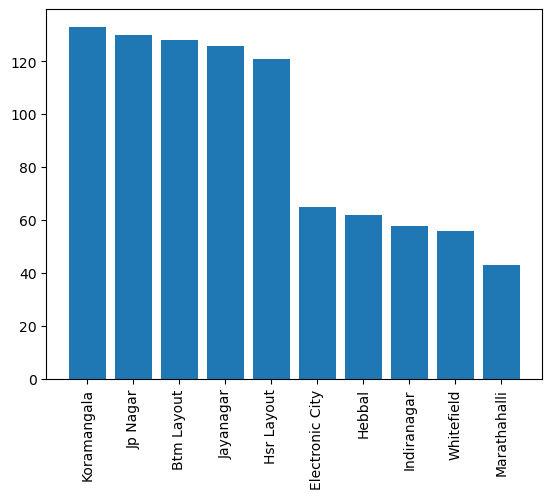

In [94]:
location = data["Location"].value_counts().head(10)
plt.bar( location.index, location.values)
plt.xticks(rotation=90)
plt.show()

<span style="font-size:12pt">Q2. How is Monthly Rent distributed across all PGs? </span>

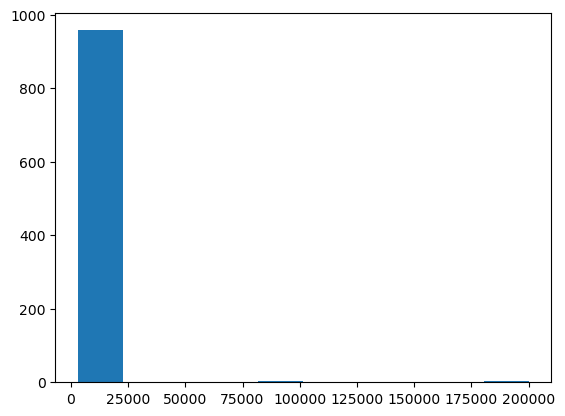

In [95]:
plt.hist(data["Monthly_Rent"])
plt.show()

So the Solution is “Most PGs have rents in the lower range, around Rs 0 – 25,000. Only a few PGs are very expensive, above ₹1,00,000. This means most PGs are affordable, and only a small number are premium options.

<span style="font-size:12pt">Q3. What is the share of each Room Type in the dataset?</span>

Text(0.5, 1.0, 'share of each Room Type')

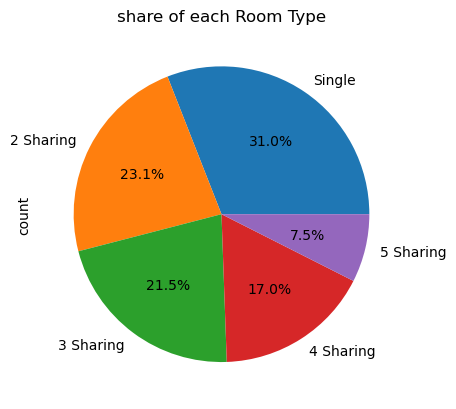

In [96]:
data["Room_Type"].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("share of each Room Type")

The chart shows the share of each room type. 
* Single rooms make up the largest part (31%),
* 2‑sharing (23%)  
* 3‑sharing (21%)
* 4‑sharing (17%)
* 5‑sharing rooms are the smallest group at 7.5%
  
This means most PGs are single or small‑sharing rooms, while big‑sharing rooms are less.

<span style="font-size:12pt">Q4. What is the relationship between Amenities Score and Monthly Rent? → Scatter Plot</span>


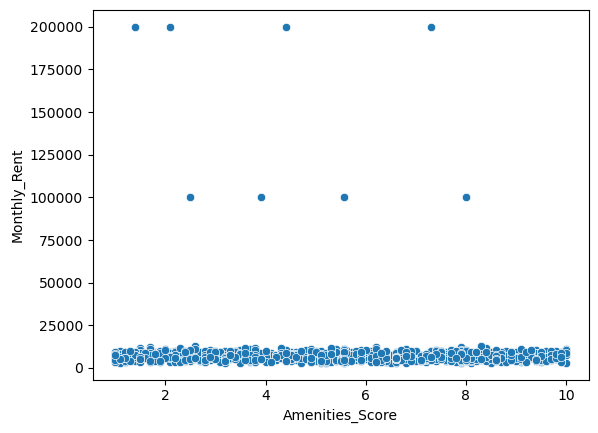

In [97]:
import seaborn as sns
sns.scatterplot(x=data["Amenities_Score"],y=data["Monthly_Rent"])
plt.show()

Most PGs have low rents, even when the amenities score is high. Only a few PGs are very expensive, with rents above Rs 1,00,000 or ₹2,00,000.
So it means there is no strong link between them.  better amenities don’t always mean higher rent.


<span style="font-size:12pt">Q5. How does Monthly Rent vary across different Room Types? 

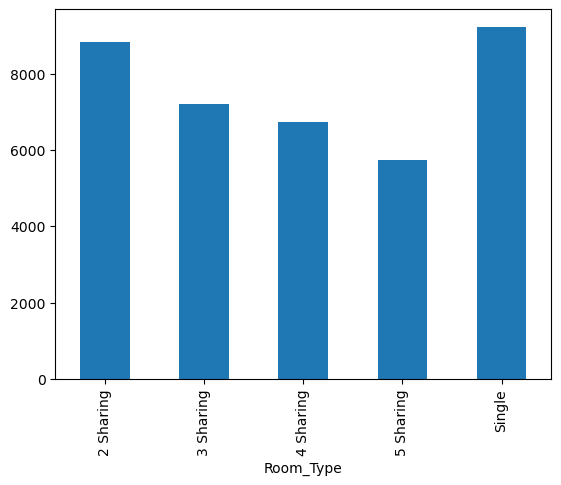

In [98]:
datas = data.groupby("Room_Type")["Monthly_Rent"].mean().round(2)
datas.plot(kind="bar")
plt.show()


<span style="font-size:12pt">Q6. How many PGs are Male, Female and Unisex?</span>

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_20956\3722771801.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data["Gender"], palette="pastel")


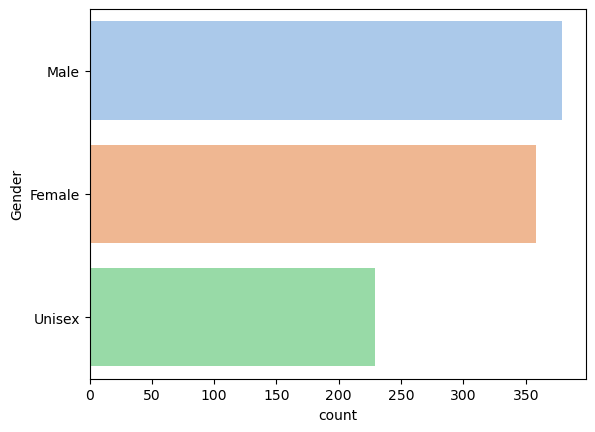

In [108]:
sns.countplot(data["Gender"], palette="pastel")
plt.show()

As per the chart, 
* PG for "Male" is having more count than others it is around counts of "400"
* PG for "Female" is in the second place and the count of around "360" PG's
* PG for "Unisex" is in the last place and it count is around "225" PG's